In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Background

## Harmonic Oscillator

The equation for an oscillator is

$$
m\frac{\textrm{d}^2x}{\textrm{d}\,t^2} + k x = 0
$$

which admits the general solution

$$
A\cos{\left(\omega_0 t + \phi\right)}
$$

where $\omega = \sqrt{k/m}$, and for any $A$ or $\phi$.

## Damped Harmonic Oscillator

In the presence of a linear resistive force, e.g., friction, the harmonic equation becomes

$$
m\frac{\textrm{d}^2x}{\textrm{d}\,t^2} + b \frac{\textrm{d}\,x}{\textrm{d}\,t} + k x = 0
$$

which admits the solution

$$
A e^{-\frac{bt}{2m}} \cos{\left(\omega' t + \phi\right)}
$$

where $\omega'$ is the dampened frequency given by $\omega'^2 = \frac{k}{m} - \left(\frac{b}{2m}\right)^2$.

In [13]:
def harmonic_oscillator(t, A0, k, m, phi0, b=None):
    omegasq = k/m

    if b is not None:
        omegasq -= (b/2/m)**2
        prefac = np.exp(-b/2/m*t)
    else:
        prefac = 1.0
     
    omega = np.sqrt(omegasq)

    ans = A0 * prefac * np.cos(omega*t + phi0)
    return ans

Text(0.5, 1.0, 'Simple Harmonic Oscillator')

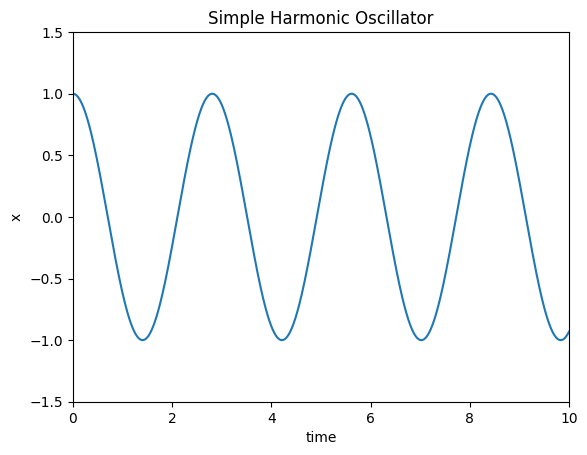

In [14]:
A0 = 1.0
k=5
m=1
phi0 = 0

omega = np.sqrt(k/m)

tlist = np.linspace(0, 10, 1000)
x = harmonic_oscillator(tlist, A0, k, m, phi0)

plt.plot(tlist, x)
plt.xlim(0, 10)
plt.ylim(-1.5, 1.5)
plt.xlabel('time')
plt.ylabel('x')
plt.title('Simple Harmonic Oscillator')

4.47213595499958


Text(0.5, 1.0, 'Damped Harmonic Oscillator')

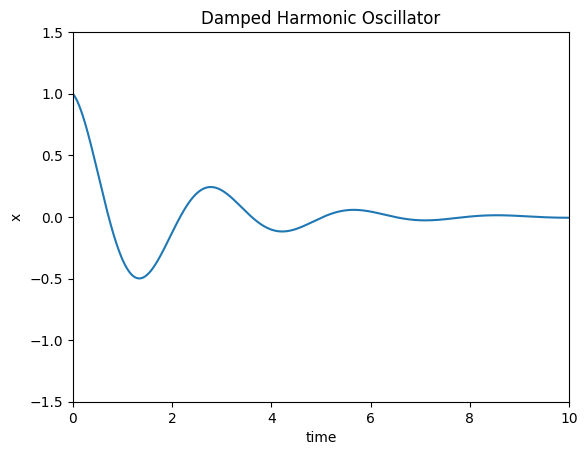

In [24]:
A0 = 1.0
k=5
m=1
b=1
phi0 = 0

print(2*np.sqrt(m*k))

omegap = np.sqrt(k/m - (b/2/m)**2)

tlist = np.linspace(0, 10, 1000)
x = harmonic_oscillator(tlist, A0, k, m, phi0, b)

plt.plot(tlist, x)
plt.xlim(0, 10)
plt.ylim(-1.5, 1.5)
plt.xlabel('time')
plt.ylabel('x')
plt.title('Damped Harmonic Oscillator')

# Generate Training Data

Let's generate training data for each of these oscillators. For each parameter, let's take the following priors (assuming also an enforcement that $k$ and $m$ are positive):

- $A_0$: $\mathcal{U}(0,2)$
- $\phi_0$: $\mathcal{U}(0, 2\pi)$
- $k$: $\mathcal{N}(5, 2.5^2)$
- $m$: $\mathcal{N}(1, 0.2^2)$
- $b$: $\mathcal{U}(0, 2\sqrt{mk})$

In [28]:
def truncnorm(rng, mu, sigma, lo=None, hi=None, size=None):
    if lo is None:
        lo = -np.inf
    if hi is None:
        hi = np.inf

    if size is None:
        # Single sample
        while True:
            x = rng.normal(mu, sigma)
            if lo <= x <= hi:
                return x

    samples = np.empty(0)
    n_needed = size
    n_try = int(np.ceil(n_needed * 1.5))

    while len(samples) < size:
        candidates = rng.normal(mu, sigma, size=n_try)
        accepted = candidates[(candidates >= lo) & (candidates <= hi)]
        samples = np.concatenate([samples, accepted])

        if len(samples) >= size:
            break

        # estimate acceptance rate from everything we've seen so far
        n_sampled_total = len(samples) + (n_try - len(accepted))  # rough running count
        efficiency = len(samples) / max(n_sampled_total, 1)
        efficiency = max(efficiency, 1e-8)  # avoid division by zero

        n_needed = size - len(samples)
        n_try = int(np.ceil(n_needed / efficiency * 1.5))

    return samples[:size]

In [55]:
from types import SimpleNamespace

def generate_samples(n, nt, damped=False, tbound=[0, 5], seed=42):
    rng = np.random.default_rng(seed)

    A0 = rng.uniform(0, 2, size=n)
    phi0 = rng.uniform(0, 2*np.pi, size=n)
    k = truncnorm(rng, mu=5, sigma=2.5, lo=0, size=n)
    m = truncnorm(rng, mu=1, sigma=0.2, lo=0, size=n)
    
    if damped:
        # b = rng.uniform(0, 2*np.sqrt(m*k), size=n)
        b = truncnorm(rng, mu=0.5*np.sqrt(m*k), sigma=0.25*np.sqrt(m*k), lo=0, hi=2*np.sqrt(m*k), size=n)
    else:
        b = np.zeros(n)
    
    # t = rng.uniform(tbound[0], tbound[1], size=(n, nt))
    t = np.linspace(tbound[0], tbound[1], nt)

    x = harmonic_oscillator(t, A0[:, None], k[:, None], m[:, None], phi0[:, None], b[:, None])

    return SimpleNamespace(x=x, t=t, A0=A0, k=k, m=m, phi0=phi0, b=b)

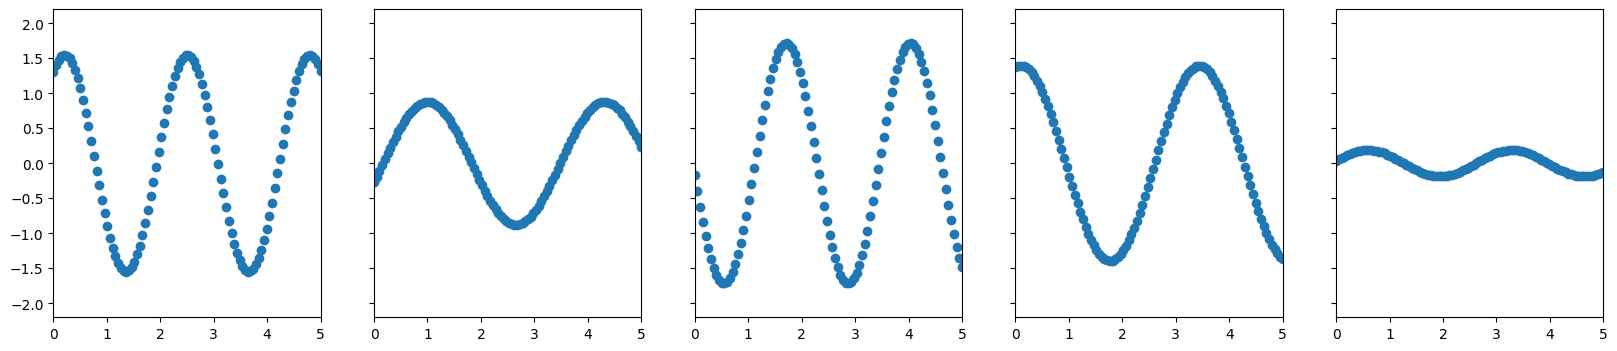

In [53]:
samples = generate_samples(100, 100)

fig, axs = plt.subplots(1, 5, figsize=(20, 4), sharex=True, sharey=True)

axs[0].set(xlim=(0, 5), ylim=(-2.2, 2.2))

for i in range(5):
    axs[i].scatter(samples.t, samples.x[i])

In [56]:
samples_damp = generate_samples(100, 100, damped=True)

fig, axs = plt.subplots(3, 5, figsize=(20, 9), sharex=True, sharey=True)

axs[0][0].set(xlim=(0, 5), ylim=(-2.2, 2.2))

for i in range(15):
    axs.ravel()[i].scatter(samples_damp.t, samples_damp.x[i])

ValueError: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (150,) and arg 1 with shape (100,).